## Configuration
Edit these values to analyze different races/drivers

In [1]:
# ========================================
# ANALYSIS CONFIGURATION
# ========================================

YEAR = 2025
RACE_ROUND = 24  # 1=Bahrain, 2=Saudi, 3=Australia, etc.
DRIVER = "NOR"   # VER, HAM, LEC, NOR, PER, etc.

# ========================================

## Setup & Imports

In [2]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import os

In [3]:
# Enable FastF1 caching for faster repeated loads
os.makedirs("fastf1_cache", exist_ok=True)
fastf1.Cache.enable_cache("fastf1_cache")

print(f"Configuration: {DRIVER} @ Round {RACE_ROUND} of {YEAR}")

Configuration: NOR @ Round 24 of 2025


## Data Loading

In [4]:
# Load race session data
try:
    session = fastf1.get_session(YEAR, RACE_ROUND, 'R')
    session.load()
    
    race_name = session.event['EventName']
    print(f"✅ Successfully loaded: {race_name} {YEAR}")
    
except Exception as e:
    print(f"❌ Error loading session: {e}")
    print(f"Please verify:")
    print(f"  - Year {YEAR} has data available")
    print(f"  - Race round {RACE_ROUND} exists for this season")
    raise

core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '63', '14', '31', '44', '27', '18', '5', '87', '55', '22', '12', '23', '6', '30', '10', '43']


✅ Successfully loaded: Abu Dhabi Grand Prix 2025


In [5]:
# Extract driver lap data
try:
    laps = session.laps
    driver_laps = laps.pick_drivers(DRIVER)
    driver_laps = driver_laps[driver_laps["LapTime"].notna()]
    
    print(f"✅ Found {len(driver_laps)} total laps for {DRIVER}")
    print(f"\nLap Overview:")
    print(driver_laps[[
        "LapNumber",
        "LapTime",
        "Stint",
        "Compound",
        "PitInTime",
        "PitOutTime"
    ]].head(10))
    
except KeyError:
    print(f"❌ Error: Driver '{DRIVER}' not found in this race")
    print(f"Available drivers: {sorted(laps['Driver'].unique())}")
    raise
except Exception as e:
    print(f"❌ Unexpected error: {e}")
    raise

✅ Found 58 total laps for NOR

Lap Overview:
     LapNumber                LapTime  Stint Compound PitInTime PitOutTime
116        1.0 0 days 00:01:33.952000    1.0   MEDIUM       NaT        NaT
117        2.0 0 days 00:01:29.893000    1.0   MEDIUM       NaT        NaT
118        3.0 0 days 00:01:29.860000    1.0   MEDIUM       NaT        NaT
119        4.0 0 days 00:01:29.841000    1.0   MEDIUM       NaT        NaT
120        5.0 0 days 00:01:29.818000    1.0   MEDIUM       NaT        NaT
121        6.0 0 days 00:01:29.820000    1.0   MEDIUM       NaT        NaT
122        7.0 0 days 00:01:29.817000    1.0   MEDIUM       NaT        NaT
123        8.0 0 days 00:01:29.510000    1.0   MEDIUM       NaT        NaT
124        9.0 0 days 00:01:29.527000    1.0   MEDIUM       NaT        NaT
125       10.0 0 days 00:01:29.635000    1.0   MEDIUM       NaT        NaT


## Data Cleaning

**F1-Specific Cleaning Strategy:**
1. Remove pit in/out laps (anomalous tire wear)
2. Keep only green flag laps (TrackStatus='1')
3. Filter out Safety Car / Virtual Safety Car periods
4. Calculate tire age within each stint

In [6]:
# Create working copy
clean_laps = driver_laps.copy()

# 1. Remove pit in/out laps (tire changes affect degradation)
initial_count = len(clean_laps)
clean_laps = clean_laps[
    clean_laps["PitInTime"].isna() & clean_laps["PitOutTime"].isna()
]
pit_laps_removed = initial_count - len(clean_laps)

# 2. Keep only green flag laps (normal racing conditions)
initial_count = len(clean_laps)
clean_laps = clean_laps[clean_laps["TrackStatus"] == '1']
yellow_laps_removed = initial_count - len(clean_laps)

print(f"Data Cleaning Summary:")
print(f"  Original laps: {len(driver_laps)}")
print(f"  - Pit in/out laps removed: {pit_laps_removed}")
print(f"  - Yellow/SC laps removed: {yellow_laps_removed}")
print(f"  ✅ Clean laps remaining: {len(clean_laps)}")

# Verify we still have data
if len(clean_laps) == 0:
    print("⚠️ Warning: No clean laps remaining after filtering!")
    print("Check if the race had unusual circumstances (red flags, etc.)")

Data Cleaning Summary:
  Original laps: 58
  - Pit in/out laps removed: 4
  - Yellow/SC laps removed: 0
  ✅ Clean laps remaining: 54


In [7]:
# Feature Engineering
# Calculate tire age within each stint
clean_laps["lap_in_stint"] = clean_laps.groupby("Stint").cumcount() + 1

# Convert lap times to seconds for modeling
clean_laps["lap_time_s"] = clean_laps["LapTime"].dt.total_seconds()

# Sort by time for weather data merge
clean_laps = clean_laps.sort_values("Time").reset_index(drop=True)

print("\nFeature Engineering Complete:")
print(clean_laps[[
    "LapNumber",
    "Stint",
    "lap_in_stint",
    "Compound",
    "lap_time_s"
]].head(10))


Feature Engineering Complete:
   LapNumber  Stint  lap_in_stint Compound  lap_time_s
0        1.0    1.0             1   MEDIUM      93.952
1        2.0    1.0             2   MEDIUM      89.893
2        3.0    1.0             3   MEDIUM      89.860
3        4.0    1.0             4   MEDIUM      89.841
4        5.0    1.0             5   MEDIUM      89.818
5        6.0    1.0             6   MEDIUM      89.820
6        7.0    1.0             7   MEDIUM      89.817
7        8.0    1.0             8   MEDIUM      89.510
8        9.0    1.0             9   MEDIUM      89.527
9       10.0    1.0            10   MEDIUM      89.635


## Weather Data Integration
Track and air temperature affect tire degradation

In [8]:
# Load weather data
weather = session.weather_data

print("Weather Data Sample:")
print(weather[["Time", "TrackTemp", "AirTemp"]].head())

# Merge weather data with laps (nearest time match)
clean_laps = pd.merge_asof(
    clean_laps,
    weather.sort_values("Time"),
    left_on="Time",
    right_on="Time",
    direction="nearest"
)

# Create interaction features for modeling
clean_laps["lap_in_stint_squared"] = clean_laps["lap_in_stint"] ** 2
clean_laps["lap_temp_interaction"] = (
    clean_laps["lap_in_stint"] * clean_laps["TrackTemp"]
)

print(f"\n✅ Weather data merged successfully")
print(f"Track Temperature Range: {clean_laps['TrackTemp'].min():.1f}°C - {clean_laps['TrackTemp'].max():.1f}°C")
print(f"Air Temperature Range: {clean_laps['AirTemp'].min():.1f}°C - {clean_laps['AirTemp'].max():.1f}°C")

Weather Data Sample:
                    Time  TrackTemp  AirTemp
0 0 days 00:01:00.108000       34.6     27.4
1 0 days 00:02:00.124000       34.4     27.4
2 0 days 00:03:00.131000       34.4     27.5
3 0 days 00:04:00.144000       34.2     27.5
4 0 days 00:05:00.164000       34.0     27.5

✅ Weather data merged successfully
Track Temperature Range: 29.0°C - 31.5°C
Air Temperature Range: 26.0°C - 26.8°C


## Tire Degradation Modeling

**Model:** Quadratic regression with temperature interaction
```
lap_time = β₀ + β₁·x + β₂·x² + β₃·(x·T)
```
where:
- x = lap in stint (tire age)
- T = track temperature
- β₁ = linear degradation rate
- β₂ = quadratic degradation (acceleration)
- β₃ = temperature sensitivity

In [9]:
# Build models for each stint
stint_results = {}

print(f"\n{'='*70}")
print(f"TIRE DEGRADATION ANALYSIS: {DRIVER} @ {race_name} {YEAR}")
print(f"{'='*70}\n")

for stint_id, stint_df in clean_laps.groupby("Stint"):
    # Prepare features
    X = stint_df[
        ["lap_in_stint", "lap_in_stint_squared", "lap_temp_interaction"]
    ].values
    y = stint_df["lap_time_s"].values
    
    # Fit model
    model = LinearRegression()
    model.fit(X, y)
    
    # Calculate predictions and metrics
    y_pred = model.predict(X)
    residuals = y - y_pred
    
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    
    # Store results
    stint_results[stint_id] = {
        "model": model,
        "rmse": rmse,
        "r2": r2,
        "mae": mae,
        "residuals": residuals,
        "data": stint_df,
        "predictions": y_pred
    }
    
    # Print results
    compound = stint_df['Compound'].iloc[0]
    num_laps = len(stint_df)
    
    print(f"Stint {int(stint_id)}: {compound} Compound")
    print(f"  Laps in stint: {num_laps}")
    print(f"  Average track temp: {stint_df['TrackTemp'].mean():.1f}°C")
    print(f"\n  Model Coefficients:")
    print(f"    β₀ (Intercept): {model.intercept_:.3f} seconds")
    print(f"    β₁ (Linear):    {model.coef_[0]:.4f} s/lap")
    print(f"    β₂ (Quadratic): {model.coef_[1]:.6f} s/lap²")
    print(f"    β₃ (Temp):      {model.coef_[2]:.6f}")
    print(f"\n  Model Performance:")
    print(f"    RMSE: {rmse:.4f}s")
    print(f"    MAE:  {mae:.4f}s")
    print(f"    R²:   {r2:.4f}")
    print(f"\n  Lap Time Statistics:")
    print(f"    Mean:    {y.mean():.3f}s")
    print(f"    Fastest: {y.min():.3f}s (lap {stint_df.iloc[y.argmin()]['lap_in_stint']:.0f})")
    print(f"    Slowest: {y.max():.3f}s (lap {stint_df.iloc[y.argmax()]['lap_in_stint']:.0f})")
    print(f"    Range:   {y.max() - y.min():.3f}s")
    print()

print(f"{'='*70}\n")


TIRE DEGRADATION ANALYSIS: NOR @ Abu Dhabi Grand Prix 2025

Stint 1: MEDIUM Compound
  Laps in stint: 15
  Average track temp: 31.3°C

  Model Coefficients:
    β₀ (Intercept): 92.810 seconds
    β₁ (Linear):    -8.5432 s/lap
    β₂ (Quadratic): 0.052160 s/lap²
    β₃ (Temp):      0.245401

  Model Performance:
    RMSE: 0.7126s
    MAE:  0.4696s
    R²:   0.5445

  Lap Time Statistics:
    Mean:    90.038s
    Fastest: 89.510s (lap 8)
    Slowest: 93.952s (lap 1)
    Range:   4.442s

Stint 2: HARD Compound
  Laps in stint: 22
  Average track temp: 30.1°C

  Model Coefficients:
    β₀ (Intercept): 90.104 seconds
    β₁ (Linear):    -0.5396 s/lap
    β₂ (Quadratic): 0.007465 s/lap²
    β₃ (Temp):      0.009575

  Model Performance:
    RMSE: 0.1478s
    MAE:  0.1112s
    R²:   0.9416

  Lap Time Statistics:
    Mean:    88.483s
    Fastest: 87.814s (lap 20)
    Slowest: 89.958s (lap 1)
    Range:   2.144s

Stint 3: HARD Compound
  Laps in stint: 17
  Average track temp: 29.4°C

  Model

## Visualizations

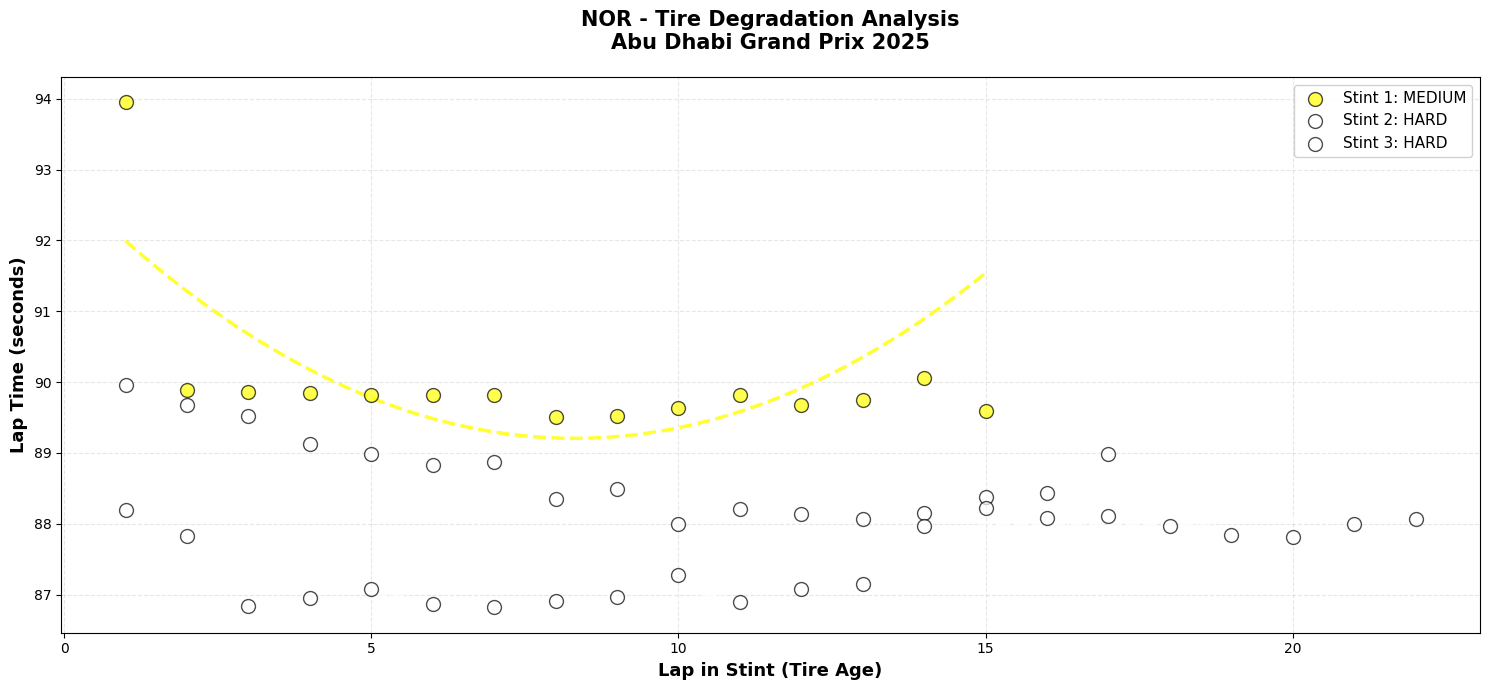

In [10]:
# Plot: Tire Degradation by Stint
fig, ax = plt.subplots(figsize=(15, 7))

colors = {'SOFT': 'red', 'MEDIUM': 'yellow', 'HARD': 'white'}

for stint_id, result in stint_results.items():
    stint_df = result['data']
    compound = stint_df['Compound'].iloc[0]
    color = colors.get(compound, 'blue')
    
    # Plot actual lap times
    ax.scatter(
        stint_df['lap_in_stint'],
        stint_df['lap_time_s'],
        c=color,
        edgecolors='black',
        s=100,
        label=f'Stint {int(stint_id)}: {compound}',
        alpha=0.7,
        zorder=3
    )
    
    # Plot regression line
    x_line = np.linspace(
        stint_df['lap_in_stint'].min(),
        stint_df['lap_in_stint'].max(),
        100
    )
    avg_temp = stint_df['TrackTemp'].mean()
    X_line = np.column_stack([x_line, x_line**2, x_line * avg_temp])
    y_line = result['model'].predict(X_line)
    
    ax.plot(
        x_line,
        y_line,
        c=color,
        linewidth=2.5,
        linestyle='--',
        alpha=0.8,
        zorder=2
    )

ax.set_xlabel('Lap in Stint (Tire Age)', fontsize=13, fontweight='bold')
ax.set_ylabel('Lap Time (seconds)', fontsize=13, fontweight='bold')
ax.set_title(
    f'{DRIVER} - Tire Degradation Analysis\n{race_name} {YEAR}',
    fontsize=15,
    fontweight='bold',
    pad=20
)
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

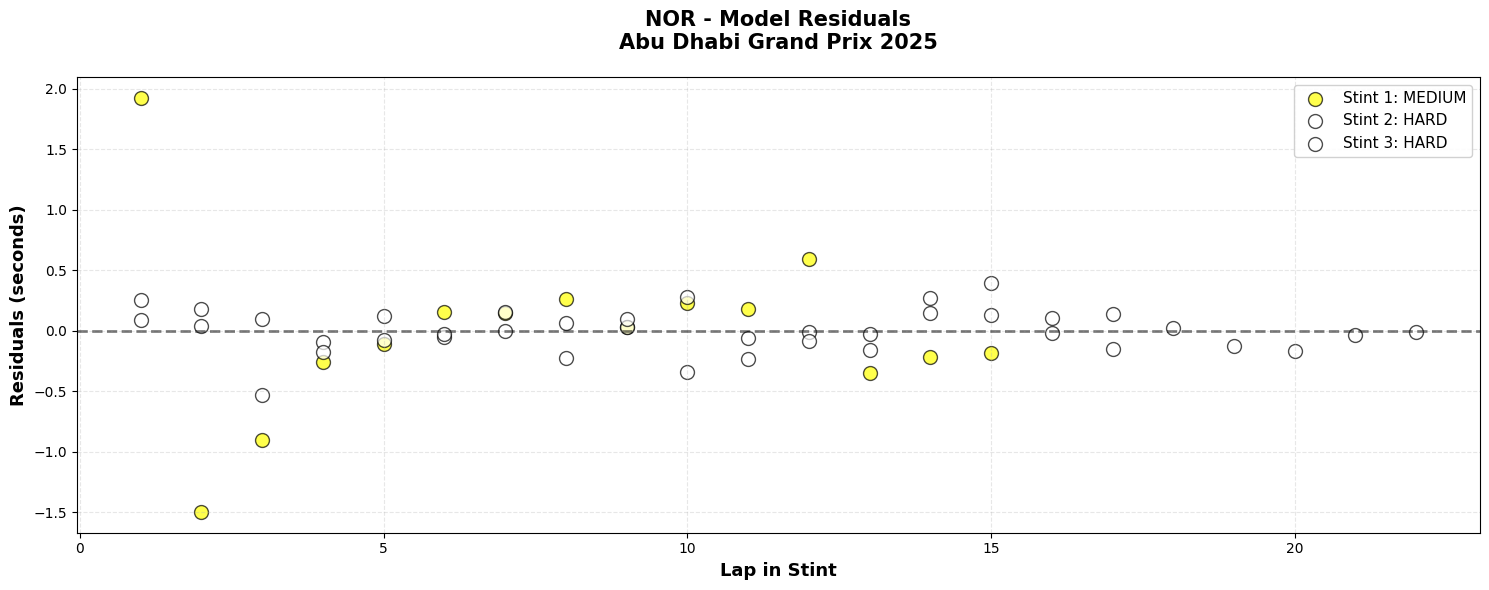

In [11]:
# Plot: Model Residuals
fig, ax = plt.subplots(figsize=(15, 6))

for stint_id, result in stint_results.items():
    stint_df = result['data']
    compound = stint_df['Compound'].iloc[0]
    color = colors.get(compound, 'blue')
    
    ax.scatter(
        stint_df['lap_in_stint'],
        result['residuals'],
        c=color,
        edgecolors='black',
        s=100,
        label=f'Stint {int(stint_id)}: {compound}',
        alpha=0.7
    )

ax.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax.set_xlabel('Lap in Stint', fontsize=13, fontweight='bold')
ax.set_ylabel('Residuals (seconds)', fontsize=13, fontweight='bold')
ax.set_title(
    f'{DRIVER} - Model Residuals\n{race_name} {YEAR}',
    fontsize=15,
    fontweight='bold',
    pad=20
)
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

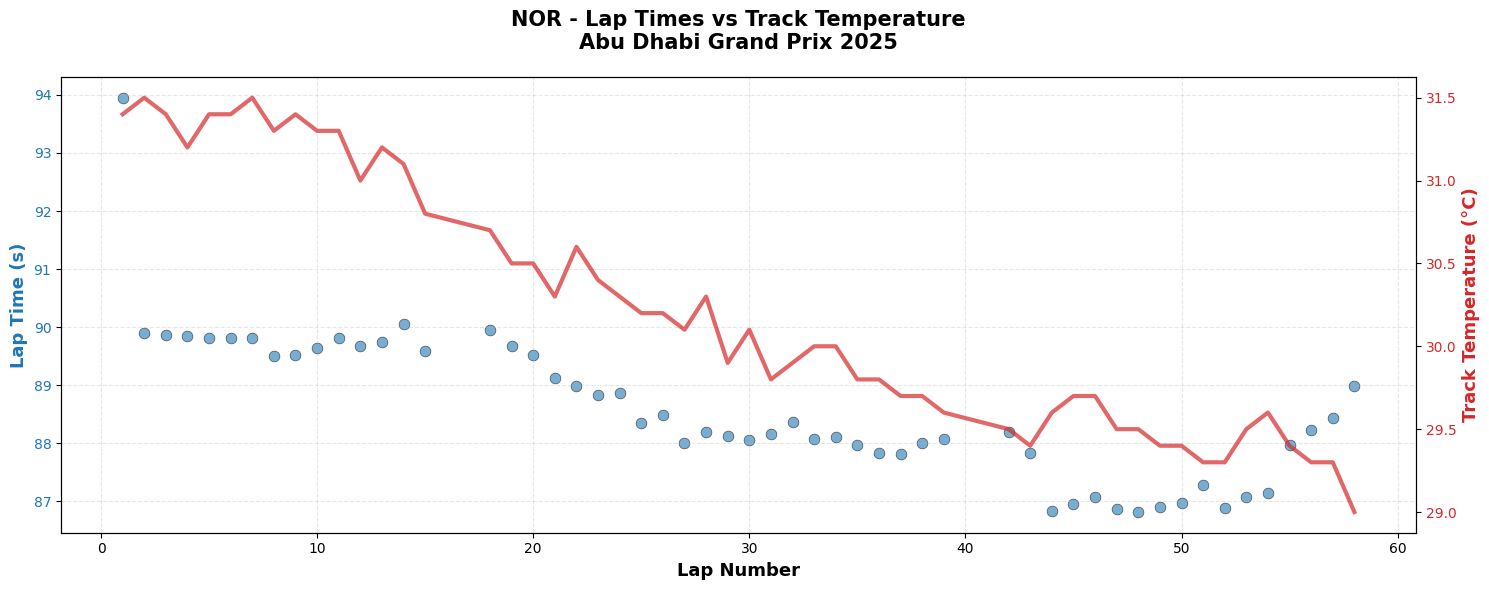

In [12]:
# Plot: Temperature Evolution
fig, ax1 = plt.subplots(figsize=(15, 6))

# Lap times on primary y-axis
ax1.set_xlabel('Lap Number', fontsize=13, fontweight='bold')
ax1.set_ylabel('Lap Time (s)', fontsize=13, fontweight='bold', color='tab:blue')
ax1.scatter(
    clean_laps['LapNumber'],
    clean_laps['lap_time_s'],
    c='tab:blue',
    alpha=0.6,
    s=60,
    edgecolors='black',
    linewidth=0.5
)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3, linestyle='--')

# Track temperature on secondary y-axis
ax2 = ax1.twinx()
ax2.set_ylabel('Track Temperature (°C)', fontsize=13, fontweight='bold', color='tab:red')
ax2.plot(
    clean_laps['LapNumber'],
    clean_laps['TrackTemp'],
    c='tab:red',
    linewidth=3,
    alpha=0.7
)
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title(
    f'{DRIVER} - Lap Times vs Track Temperature\n{race_name} {YEAR}',
    fontsize=15,
    fontweight='bold',
    pad=20
)
plt.tight_layout()
plt.show()

## Race Summary

In [13]:
print(f"\n{'='*70}")
print(f"RACE SUMMARY: {DRIVER}")
print(f"{race_name} {YEAR}")
print(f"{'='*70}\n")

print(f"📊 LAP STATISTICS")
print(f"  Total laps completed: {len(driver_laps)}")
print(f"  Clean laps analyzed: {len(clean_laps)}")
print(f"  Number of stints: {clean_laps['Stint'].nunique()}")
print(f"  Average lap time: {clean_laps['lap_time_s'].mean():.3f}s")
fastest_lap_idx = clean_laps['lap_time_s'].idxmin()
print(f"  Fastest lap: {clean_laps.loc[fastest_lap_idx, 'lap_time_s']:.3f}s (Lap {clean_laps.loc[fastest_lap_idx, 'LapNumber']:.0f})")

print(f"\n🏁 TIRE STRATEGY")
for compound in clean_laps['Compound'].unique():
    laps_on_compound = len(clean_laps[clean_laps['Compound'] == compound])
    avg_time = clean_laps[clean_laps['Compound'] == compound]['lap_time_s'].mean()
    print(f"  {compound}: {laps_on_compound} laps (avg: {avg_time:.3f}s)")

print(f"\n🌡️ WEATHER CONDITIONS")
print(f"  Track temp: {clean_laps['TrackTemp'].min():.1f}°C - {clean_laps['TrackTemp'].max():.1f}°C (avg: {clean_laps['TrackTemp'].mean():.1f}°C)")
print(f"  Air temp: {clean_laps['AirTemp'].min():.1f}°C - {clean_laps['AirTemp'].max():.1f}°C (avg: {clean_laps['AirTemp'].mean():.1f}°C)")
print(f"  Humidity: {clean_laps['Humidity'].min():.0f}% - {clean_laps['Humidity'].max():.0f}%")

if clean_laps['PitInTime'].notna().any() or driver_laps['PitInTime'].notna().any():
    num_pitstops = driver_laps['PitInTime'].notna().sum()
    print(f"\n🔧 PIT STOPS")
    print(f"  Number of stops: {num_pitstops}")

print(f"\n{'='*70}\n")


RACE SUMMARY: NOR
Abu Dhabi Grand Prix 2025

📊 LAP STATISTICS
  Total laps completed: 58
  Clean laps analyzed: 54
  Number of stints: 3
  Average lap time: 88.586s
  Fastest lap: 86.818s (Lap 48)

🏁 TIRE STRATEGY
  MEDIUM: 15 laps (avg: 90.038s)
  HARD: 39 laps (avg: 88.028s)

🌡️ WEATHER CONDITIONS
  Track temp: 29.0°C - 31.5°C (avg: 30.2°C)
  Air temp: 26.0°C - 26.8°C (avg: 26.4°C)
  Humidity: 60% - 66%

🔧 PIT STOPS
  Number of stops: 2


